# Retirement choice speed benchmarks

**Paper**: Dobrescu and Shanker (2022), *A Fast Upper Envelope Scan Method for Discrete-Continuous Dynamic Programming*

This benchmarking notebook solves the discrete retirement choice model from [Iskhakov et al. (2017)](https://onlinelibrary.wiley.com/doi/abs/10.3982/QE643) using FUES and benchmarks against other upper-envelope methods.

We benchmark FUES against three alternatives: MSS (monotone segment selection, Iskhakov et al. 2017, via [HARK](https://econ-ark.org)), LTM (local triangulation, Druedahl 2021, via [ConSav](https://github.com/NumEconCopenhagen/ConsumptionSaving)), and RFC (rooftop cut, Dobrescu & Shanker 2024).





> **Note on the model files**
>
> This notebook loads the retirement model from a set of declarative YAML files written in `dolo+`.
> In this declarative language, a **stage** can be thought of as just one self-contained Bellman operator of the dynamic problem, such as the worker's consumption choice, the retiree's consumption choice, or the labour-market decision. A full period is built by linking these stages together as a graph representing the choice structure of the model.
>
> The YAML format used here is called `dolo+`. It is simply a structured, machine-readable way of writing down the model's states, controls, transitions, and Bellman objects. You do **not** need to learn that syntax to follow this notebook. 



Load the basic imports, file paths, and model solver. We refer to a model as a `nest`, which is essentially a directed graph built up from the stages.
The function `solve_nest` solves a model by running backward induction on the stages in the graph.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time, sys, os, yaml, tempfile
from pathlib import Path
from IPython.display import Image, Markdown, HTML, display

# ── Repo paths (robust: walk up until we find pyproject.toml) ──
_here = Path(os.path.abspath('')).resolve()
REPO = _here
for _ in range(10):
    if (REPO / 'pyproject.toml').exists():
        break
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'src'))

SYNTAX_DIR = REPO / 'examples' / 'retirement' / 'syntax'

# ── Imports ──
from examples.retirement.solve import solve_nest  # main solver of a model 
from examples.retirement.outputs import (
    get_policy, get_timing, get_solution_at_age,  # helper functions that unpack and extract from the solution dict
    euler, consumption_deviation,
    # Straight-forward plotters for this notebook (consistent Nord style)
    setup_nb_style,
    nb_plot_egrids, nb_plot_egm_interactive,
    nb_plot_cons_ages, nb_plot_scaling,
)

# ── Apply notebook style globally ──
setup_nb_style()
print(f'REPO: {REPO}')

REPO: /Users/akshayshanker/Research/Repos/FUES2026/FUES


## 1. Model

An agent lives for $T$ periods. Each period she holds assets $a \geq 0$ and makes two choices: a **discrete** choice $d \in \{\text{work}, \text{retire}\}$ and a **continuous** choice of consumption $c$. Working yields wage income $y$ but costs disutility $\tau$; retirement is absorbing. Assets earn gross return $(1{+}r)$.

The sequence of events within a period are
- workers and retirees start with beginning-of-period assets $a$ and $a_{\text{ret}}$ respectively
- earn returns and receive income to produce cash-on-hand $w = (1{+}r)a + y$ for workers or $w_{\text{ret}} = (1{+}r)a_{\text{ret}}$ for retirees
- consumes $c$, leaving end-of-period savings $b = w - c$ (or $b_{\text{ret}} = w_{\text{ret}} - c$)
- inter-period transition maps $b \to a$ and $b_{\text{ret}} \to a_{\text{ret}}$ for the next period; retirement is absorbing.
### Stage decomposition

Each period can be translated to a directed graph of self-contained modular *stages*, following [Carroll (2026)](https://llorracc.github.io/SolvingMicroDSOPs/); see [Carroll and Shanker (2026)](https://bright-forest.github.io/bellman-ddsl/theory/MDP-foundations/) for the formal framework. The retirement model has three stages:

1. **`labour_mkt_decision`** (branching) — discrete choice: $\max(\mathrm{v}_{\succ}^{\text{work}} - \tau,\; \mathrm{v}_{\succ}^{\text{retire}})$. Assets $a$ pass through unchanged.
2. **`work_cons`** (continuous, EGM + FUES) — worker consumption: $a \to w \to b$. The continuation value $\mathrm{v}_{\succ}$ is non-concave; FUES recovers the correct envelope.
3. **`retire_cons`** (continuous, EGM) — retiree consumption: $a_{\text{ret}} \to w_{\text{ret}} \to b_{\text{ret}}$. Standard concave problem.

Note that workers arrive at $a$ (into the branching stage); retirees arrive at $a_{\text{ret}}$ (directly into `retire_cons`). If a worker chooses to retire, they become a retiree and move into retiree consumption problem,  `retire_cons`, as those who entered the period as a retiree. 


<div markdown="0">
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 680 280" style="max-width:680px;width:100%;">
  <defs>
    <style>
      .dag-edge   { fill: none; stroke: currentColor; stroke-width: 1.2px; stroke-linecap: round; }
      .dag-arrow  { fill: currentColor; }
      .dag-perch  { fill: var(--md-default-bg-color, #fff); stroke: currentColor; stroke-width: 1.2px; }
      .dag-stg    { fill: currentColor; stroke: none; }
      .dag-bound  { fill: none; stroke: currentColor; stroke-width: 0.8px; stroke-dasharray: 4 3; opacity: 0.25; }
      .dag-field  { font-family: Georgia, 'Times New Roman', serif; font-style: italic; font-size: 15px; fill: currentColor; }
      .dag-sub    { font-size: 10.5px; }
      .dag-ptag   { font-family: Georgia, 'Times New Roman', serif; font-style: italic; font-size: 9.5px; fill: currentColor; opacity: 0.40; }
      .dag-slabel { font-family: 'Inter', 'Helvetica Neue', sans-serif; font-size: 11px; fill: currentColor; }
      .dag-branch { font-family: 'Inter', 'Helvetica Neue', sans-serif; font-size: 10px; fill: currentColor; font-style: italic; }
      .dag-period { font-family: 'Inter', 'Helvetica Neue', sans-serif; font-size: 9.5px; fill: currentColor; opacity: 0.30; font-style: italic; }
      .dag-legend { font-family: 'Inter', 'Helvetica Neue', sans-serif; font-size: 8px; fill: currentColor; opacity: 0.45; }
    </style>
    <marker id="dag-ah" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L8,3 L0,6 L1.5,3 Z" class="dag-arrow"/>
    </marker>
  </defs>
  <rect class="dag-bound" x="14" y="14" width="652" height="252" rx="8"/>
  <text class="dag-period" x="26" y="30">LifecyclePeriod</text>
  <circle class="dag-stg" cx="548" cy="27" r="3.5"/>
  <text class="dag-legend" x="555" y="30">stage</text>
  <circle class="dag-perch" cx="600" cy="27" r="3.5"/>
  <text class="dag-legend" x="607" y="30">perch field</text>
  <circle class="dag-perch" cx="68" cy="105" r="6"/>
  <text class="dag-field" x="68" y="88" text-anchor="middle">a</text>
  <circle class="dag-perch" cx="68" cy="210" r="6"/>
  <text class="dag-field" x="68" y="198" text-anchor="middle">a<tspan class="dag-sub" dy="3">ret</tspan></text>
  <circle class="dag-stg" cx="220" cy="105" r="7"/>
  <text class="dag-slabel" x="220" y="82" text-anchor="middle">labour_mkt_decision</text>
  <circle class="dag-stg" cx="415" cy="65" r="7"/>
  <text class="dag-slabel" x="415" y="48" text-anchor="middle">work_cons</text>
  <circle class="dag-stg" cx="415" cy="192" r="7"/>
  <text class="dag-slabel" x="415" y="222" text-anchor="middle">retire_cons</text>
  <circle class="dag-perch" cx="575" cy="65" r="6"/>
  <text class="dag-field" x="575" y="48" text-anchor="middle">b</text>
  <circle class="dag-perch" cx="575" cy="192" r="6"/>
  <text class="dag-field" x="575" y="180" text-anchor="middle">b<tspan class="dag-sub" dy="3">ret</tspan></text>
  <line class="dag-edge" x1="75" y1="105" x2="212" y2="105" marker-end="url(#dag-ah)"/>
  <path class="dag-edge" d="M228,102 C265,82 360,65 407,65" marker-end="url(#dag-ah)"/>
  <text class="dag-branch" x="310" y="72">work</text>
  <path class="dag-edge" d="M228,109 C268,140 355,182 407,192" marker-end="url(#dag-ah)"/>
  <text class="dag-branch" x="298" y="165">retire</text>
  <path class="dag-edge" d="M75,210 C185,210 335,198 407,193" marker-end="url(#dag-ah)"/>
  <line class="dag-edge" x1="423" y1="65" x2="568" y2="65" marker-end="url(#dag-ah)"/>
  <line class="dag-edge" x1="423" y1="192" x2="568" y2="192" marker-end="url(#dag-ah)"/>
</svg>
</div>

### Stage operators

Within each each stage, the state space is represented at three nodes: arrival ($\mathsf{X}_{\prec}$), decision ($\mathsf{X}$), and continuation ($\mathsf{X}_{\succ}$). Solving proceeds backward: given a continuation-value function $\mathrm{v}_{\succ}$ on $\mathsf{X}_{\succ}$, the decision mover $\mathbb{B}$ produces the decision-value function $\mathrm{v}$ on $\mathsf{X}$, and the arrival mover $\mathbb{I}$ passes $\mathrm{v}$ back to $\mathsf{X}_{\prec}$. Throughout, $\partial\mathrm{v}$ denotes the derivative of $\mathrm{v}$ with respect to the stage's own state variable.

The term mover here refers to operations that move from one node to the next (either forward or backward). The mathematical aspect of the mover is simply a functional operator -- but the mover captures an object that may also contain computational representations of how the operator is implemented on the computer. 

<details style="border-left:3px solid #7c4dff;padding:8px 16px;margin:12px 0;background:rgba(124,77,255,0.04);border-radius:4px;">
<summary style="cursor:pointer;font-weight:600;font-size:0.95em;"><code>work_cons</code> — worker consumption (EGM + FUES)</summary>

**Decision mover $\mathbb{B}$** &ensp; (continuation $\to$ decision)

Let $\mathrm{v}_{\succ}(b)$ be the continuation value at end-of-period savings $b$, and $\partial\mathrm{v}_{\succ}(b)$ its derivative. The worker's cash-on-hand is $w$ and the budget constraint is $b = w - c$. The decision mover solves:

$$(\mathbb{B}\,\mathrm{v}_{\succ})(w) = \mathrm{v}(w) = \max_c\bigl\{\log(c) + \beta\,\mathrm{v}_{\succ}(w - c)\bigr\}$$

The first-order condition is $1/c = \beta\,\partial\mathrm{v}_{\succ}(b)$.

*EGM.* &ensp; Given an exogenous grid $\{b_0^{\#},\dots,b_N^{\#}\}$ on the continuation state, the FOC yields optimal consumption $c_i^{\#} = \bigl(\beta\,\partial\mathrm{v}_{\succ}(b_i^{\#})\bigr)^{-1}$ and the budget constraint recovers the endogenous grid $w_i^{\#} = b_i^{\#} + c_i^{\#}$. Each pair $(w_i^{\#},\, c_i^{\#})$ satisfies the FOC, and the corresponding value is $q_i^{\#} = \log(c_i^{\#}) + \beta\,\mathrm{v}_{\succ}(b_i^{\#})$.

*Non-concavity.* &ensp; The worker's $\mathrm{v}_{\succ}$ is the upper envelope of concave functions (one for each future discrete-choice sequence) and is not itself concave. As a result the endogenous grid $\{w_i^{\#}\}$ may be non-monotone, and the points $(w_i^{\#},\, q_i^{\#})$ define a correspondence rather than a function. An upper-envelope algorithm recovers the monotone upper envelope of $\{(w_i^{\#},\, q_i^{\#})\}$, thereby approximating $\mathrm{v}$. This is where FUES comes in.

**Arrival mover $\mathbb{I}$** &ensp; (decision $\to$ arrival)

The arrival transition is $w = (1{+}r)a + y$, so:

$$(\mathbb{I}\mathrm{v})(a) = \mathrm{v}\bigl((1{+}r)a + y\bigr)$$

The chain rule gives $\partial\mathrm{v}_{\prec}(a) = (1{+}r)\,\partial\mathrm{v}(w)$, and the envelope theorem yields $\partial\mathrm{v}(w) = 1/c$.

</details>

<details style="border-left:3px solid #00897b;padding:8px 16px;margin:12px 0;background:rgba(0,137,123,0.04);border-radius:4px;">
<summary style="cursor:pointer;font-weight:600;font-size:0.95em;"><code>retire_cons</code> — retiree consumption (EGM, concave)</summary>

**Decision mover $\mathbb{B}$** &ensp; (continuation $\to$ decision)

Let $\mathrm{v}_{\succ}(b_{\text{ret}})$ be the continuation value at retiree savings $b_{\text{ret}}$, and $\partial\mathrm{v}_{\succ}(b_{\text{ret}})$ the marginal value. The retiree's cash-on-hand is $w_{\text{ret}}$ and the budget constraint is $b_{\text{ret}} = w_{\text{ret}} - c$. The decision mover is:

$$(\mathbb{B}\mathrm{v}_{\succ})(w_{\text{ret}}) = \mathrm{v}(w_{\text{ret}}) = \max_c\bigl\{\log(c) + \beta\,\mathrm{v}_{\succ}(b_{\text{ret}})\bigr\}$$

such that $b_{\text{ret}} = w_{\text{ret}} - c$. The first-order condition is $1/c = \beta\,\partial\mathrm{v}_{\succ}(b_{\text{ret}})$.

*EGM.* &ensp; Given a grid on $b_{\text{ret}}$, recover $c_i^{\#} = \bigl(\beta\,\partial\mathrm{v}_{\succ}(b_{\text{ret},i}^{\#})\bigr)^{-1}$ and $w_{\text{ret},i}^{\#} = b_{\text{ret},i}^{\#} + c_i^{\#}$. Here $\mathrm{v}_{\succ}$ is concave (retirement is absorbing), so EGM produces a monotone endogenous grid and no upper-envelope step is needed.

**Arrival mover $\mathbb{I}$** &ensp; (decision $\to$ arrival)

The arrival transition is $w_{\text{ret}} = (1{+}r)\,a_{\text{ret}}$ (no income), so:

$$(\mathbb{I}\mathrm{v})(a_{\text{ret}}) = \mathrm{v}\bigl((1{+}r)\,a_{\text{ret}}\bigr)$$

and $\partial\mathrm{v}_{\prec}(a_{\text{ret}}) = (1{+}r)\,\partial\mathrm{v}(w_{\text{ret}})$.

</details>

<details style="border-left:3px solid #1565c0;padding:8px 16px;margin:12px 0;background:rgba(21,101,192,0.04);border-radius:4px;">
<summary style="cursor:pointer;font-weight:600;font-size:0.95em;"><code>labour_mkt_decision</code> — discrete branching</summary>

**Decision mover $\mathbb{B}$** &ensp; (continuation $\to$ decision)

The branching stage receives the arrival values from the two consumption stages: $\mathrm{v}_{\succ}^{\text{work}}(a)$ from `work_cons` and $\mathrm{v}_{\succ}^{\text{retire}}(a)$ from `retire_cons`. Assets $a$ pass through unchanged (identity transitions). The decision mover is the discrete-choice $\max$:

$$(\mathbb{B}\mathrm{v}_{\succ})(a) = \mathrm{v}(a) = \max\!\bigl(\mathrm{v}_{\succ}^{\text{work}}(a) - \tau,\;\; \mathrm{v}_{\succ}^{\text{retire}}(a)\bigr)$$

**Arrival mover $\mathbb{I}$** &ensp; (decision $\to$ arrival)

Identity: $(\mathbb{I}\mathrm{v})(a) = \mathrm{v}(a)$.

</details>

---

> **Sequential form.** &ensp; Composing the three stage operators and substituting the transitions recovers the traditional sequential recursive Bellman equations. Writing $V_t^1$ for the worker's arrival value and $V_t^0$ for the retiree's:
>
> $$V_t^1(a) = \max_{d}\; Q_t^d(a), \qquad Q_t^{\text{work}}(a) = \max_c \bigl\{ \log(c) - \tau + \beta\, V_{t+1}^1\bigl((1{+}r)a + y - c\bigr) \bigr\}$$
>
> $$Q_t^{\text{retire}}(a) = \max_c \bigl\{ \log(c) + \beta\, V_{t+1}^0\bigl((1{+}r)a - c\bigr) \bigr\}, \qquad V_t^0(a) = \max_c \bigl\{ \log(c) + \beta\, V_{t+1}^0\bigl((1{+}r)a - c\bigr) \bigr\}$$
>
>

Let us load the stage syntax templates from the `syntax` directory for each of the stages above.

In [2]:
# ── Display the stage YAML declarations (collapsible) ──
stage_names = ['work_cons', 'retire_cons', 'labour_mkt_decision']
_parts = []
for name in stage_names:
    path = SYNTAX_DIR / 'stages' / name / f'{name}.yaml'
    txt = path.read_text().rstrip()
    _parts.append(
        f'<details><summary><code>{name}</code> &ensp;'
        f'<span style="opacity:.45;font-size:.85em">{path.relative_to(REPO)}</span>'
        f'</summary><pre style="margin:4px 0;font-size:12px;line-height:1.45">{txt}</pre></details>'
    )
display(HTML('\n'.join(_parts)))

## 2. Calibration and settings

No parameters are hard-coded in Python. Let us load the baseline calibration and settings from the `syntax` directory to see what they look like.

In [3]:
# ── Display calibration and settings (collapsible) ──
_parts = []
for fname in ['calibration.yaml', 'settings.yaml']:
    path = SYNTAX_DIR / fname
    txt = path.read_text().rstrip()
    _parts.append(
        f'<details><summary><code>{fname}</code></summary>'
        f'<pre style="margin:4px 0;font-size:12px;line-height:1.45">{txt}</pre></details>'
    )
display(HTML('\n'.join(_parts)))

## 3. Solve 

`solve_nest` is the single entry point. It loads the YAML files, applies the three functors (methodize, configure, calibrate) to each stage, builds the model, and runs backward induction according to the stage graph above.
We can override the baseline settings and calibrations by passing `calib_overrides` and `config_overrides` to `solve_nest`. We can also select the upper-envelope method via `method='FUES'`, `'DCEGM'`, `'RFC'`, or `'CONSAV'`.

Note: the `dolo+` declarative syntax is solver-agnostic — `solve_nest` is built as part of this repo, not part of the `dolo+` implementation.

In [4]:
# ── Warmup (JIT compile) then timed solve ──
# Solve for 50 periods (longer horizon shows more kinks)
_, model, stage_ops, waves = solve_nest(SYNTAX_DIR, method='FUES', config_overrides={'T': 50})

nest, model, stage_ops, waves = solve_nest(
    SYNTAX_DIR, method='FUES', config_overrides={'T': 50},
    model=model, stage_ops=stage_ops, waves=waves)

print(f'Model: T={model.T}, grid_size={model.grid_size}, '
      f'beta={model.beta}, delta={model.delta}, y={model.y}')
print(f'Euler error: {euler(model, get_policy(nest, "c")):.6f}')

# ── Override: lower beta and increase grid size ──
nest2, model2, _, _ = solve_nest(
    SYNTAX_DIR, method='FUES',
    calib_overrides={'beta': 0.91},
    config_overrides={'grid_size': 3000, 'T': 50})

print(f'\nWith overrides: beta={model2.beta}, grid_size={model2.grid_size}')
print(f'Euler error: {euler(model2, get_policy(nest2, "c")):.6f}')

Model: T=50, grid_size=3000, beta=0.96, delta=1, y=20
Euler error: -1.562364

With overrides: beta=0.91, grid_size=3000
Euler error: -1.029653


### 3.1 EGM grid plots

The plots below show the raw EGM correspondence (red circles), FUES-refined points (blue crosses), the value function line (black), and estimated intersection points (green stars). We plot the solution from the second solve above (lower $\beta$).

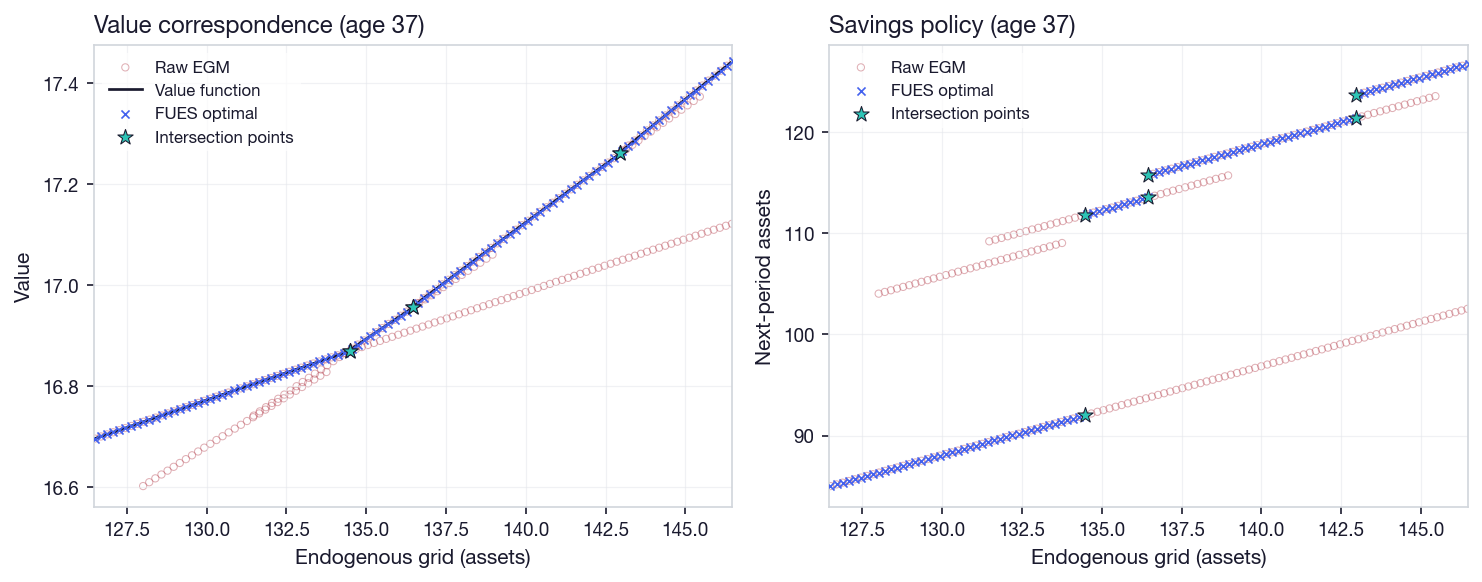

In [5]:
# ── EGM grid with FUES refinement (static, notebook style) ──
plot_age = 37
fig = nb_plot_egrids(nest2, model2, age=plot_age)
plt.show()

**Interactive plots**

Make interactive plots (only for local run).

In [6]:
# ── Interactive EGM grid plot (local run only — Plotly) ──
try:
    from examples.retirement.outputs import nb_plot_egm_interactive
    fig = nb_plot_egm_interactive(nest2, model2, age=plot_age, pad=10)
    fig.show()
except Exception:
    print('Interactive plot skipped (requires local Jupyter with Plotly).')

### 3.2 Consumption policy across ages

`nb_plot_cons_ages` shows consumption as a function of assets at three ages. The discontinuous jumps correspond to the retirement decision — agents with wealth above the threshold retire.

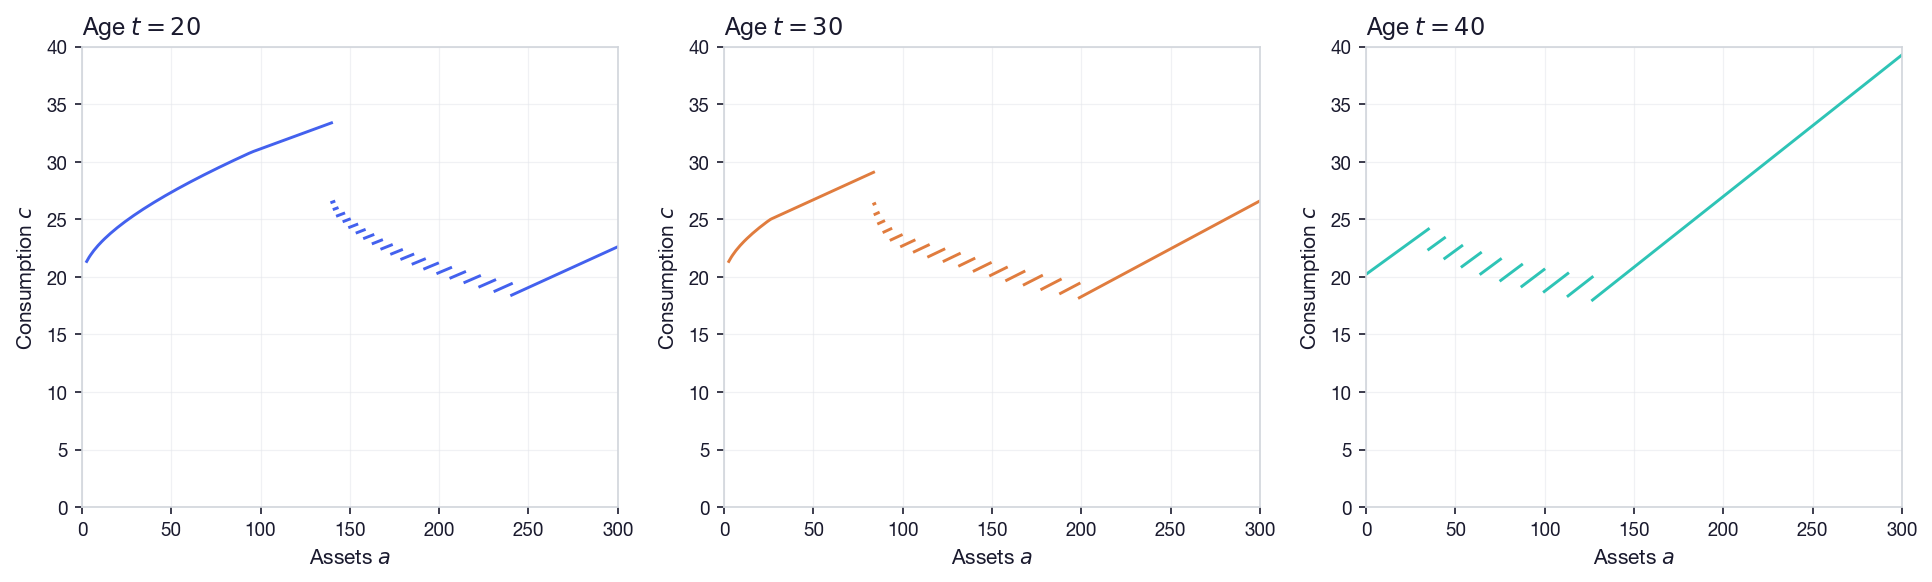

In [7]:
# ── Consumption policy at multiple ages ──
from examples.retirement.outputs import nb_plot_cons_ages

fig = nb_plot_cons_ages(nest, model, ages=(20, 30, 40))
plt.show()

## 4. Method comparison

At this calibration, all four upper-envelope methods deliver essentially the same solution quality: the reported Euler errors are extremely close, and the small differences are numerical rather than economically meaningful. The substantive comparison is therefore computation speed.

In [8]:
# ── Solve with all four methods (T=50) ──
methods = ['FUES', 'DCEGM', 'RFC', 'CONSAV']
# Display labels (API uses DCEGM/CONSAV internally)
_DISPLAY = {'FUES': 'FUES', 'DCEGM': 'MSS', 'RFC': 'RFC', 'CONSAV': 'LTM'}
results = {}

for method in methods:
    _, m_, ops_, w_ = solve_nest(SYNTAX_DIR, method=method, config_overrides={'T': 50})
    nest_m, model_m, _, _ = solve_nest(
        SYNTAX_DIR, method=method, config_overrides={'T': 50},
        model=m_, stage_ops=ops_, waves=w_)
    c_pol = get_policy(nest_m, 'c')
    ue_t, solve_t = get_timing(nest_m)
    results[method] = {
        'euler': euler(model_m, c_pol),
        'ue_ms': ue_t * 1000,
        'total_ms': solve_t * 1000,
    }

# ── Results table ──
print(f'{"Method":>8s} | {"Euler Error":>12s} | {"UE (ms)":>10s} | {"Total (ms)":>12s}')
print('-' * 50)
for m in methods:
    r = results[m]
    print(f'{_DISPLAY[m]:>8s} | {r["euler"]:>12.6f} | {r["ue_ms"]:>10.3f} | {r["total_ms"]:>12.3f}')

  Method |  Euler Error |    UE (ms) |   Total (ms)
--------------------------------------------------
    FUES |    -1.562364 |      0.143 |        0.248
     MSS |    -1.562400 |      5.558 |        5.704
     RFC |    -1.567222 |      4.644 |        4.789
     LTM |    -1.562909 |      6.033 |        6.194


## 5. Scaling: upper envelope time vs grid size

We sweep grid sizes from 1,000 to 15,000 and compare upper-envelope time across methods. FUES remains the fastest method throughout, with a much smaller constant factor than the alternatives.

MSS and RFC both scale approximately linearly in this experiment and stay relatively close to one another. LTM is competitive only on the very smallest grids, but its cost rises much more quickly and it is overtaken by the time we reach the medium-sized grids used in the main comparison.

In [9]:
# ── Scaling sweep (equal steps for visual linearity check) ──
# Operators take the grid as an argument, so we build them once
# per method (JIT compiles once) and reuse across all grid sizes.
import gc

grid_sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000]
scaling = {m: [] for m in methods}

# Build + JIT-warmup operators once per method (smallest grid).
# Operators take grid as argument so they work with any size.
_cached = {}
for method in methods:
    _, _, ops_, w_ = solve_nest(
        SYNTAX_DIR, method=method,
        config_overrides={'grid_size': grid_sizes[0], 'T': 50})
    _cached[method] = (ops_, w_)

for gs in grid_sizes:
    for method in methods:
        ops_, w_ = _cached[method]
        n, _, _, _ = solve_nest(
            SYNTAX_DIR, method=method,
            config_overrides={'grid_size': gs, 'T': 50},
            stage_ops=ops_, waves=w_)
        ue, _ = get_timing(n)
        scaling[method].append(ue * 1000)
        del n
    gc.collect()
    print(f'grid_size={gs:>6d}  '
          + '  '.join(f'{m}: {scaling[m][-1]:.2f}ms' for m in methods))

grid_size=  1000  FUES: 0.07ms  DCEGM: 1.84ms  RFC: 1.64ms  CONSAV: 0.66ms
grid_size=  2000  FUES: 0.09ms  DCEGM: 4.12ms  RFC: 3.48ms  CONSAV: 2.64ms
grid_size=  3000  FUES: 0.14ms  DCEGM: 6.30ms  RFC: 5.00ms  CONSAV: 5.93ms
grid_size=  4000  FUES: 0.17ms  DCEGM: 7.21ms  RFC: 6.77ms  CONSAV: 10.28ms
grid_size=  5000  FUES: 0.27ms  DCEGM: 8.91ms  RFC: 8.50ms  CONSAV: 17.09ms
grid_size=  6000  FUES: 0.29ms  DCEGM: 10.87ms  RFC: 10.24ms  CONSAV: 23.37ms
grid_size=  7000  FUES: 0.40ms  DCEGM: 12.94ms  RFC: 14.64ms  CONSAV: 31.49ms
grid_size=  8000  FUES: 0.38ms  DCEGM: 14.76ms  RFC: 14.90ms  CONSAV: 41.29ms
grid_size=  9000  FUES: 0.45ms  DCEGM: 19.42ms  RFC: 20.93ms  CONSAV: 53.89ms
grid_size= 10000  FUES: 0.49ms  DCEGM: 18.40ms  RFC: 18.23ms  CONSAV: 63.92ms
grid_size= 11000  FUES: 0.58ms  DCEGM: 24.18ms  RFC: 20.71ms  CONSAV: 84.55ms
grid_size= 12000  FUES: 0.63ms  DCEGM: 22.72ms  RFC: 23.76ms  CONSAV: 91.61ms
grid_size= 13000  FUES: 0.64ms  DCEGM: 25.93ms  RFC: 24.18ms  CONSAV: 108.89m

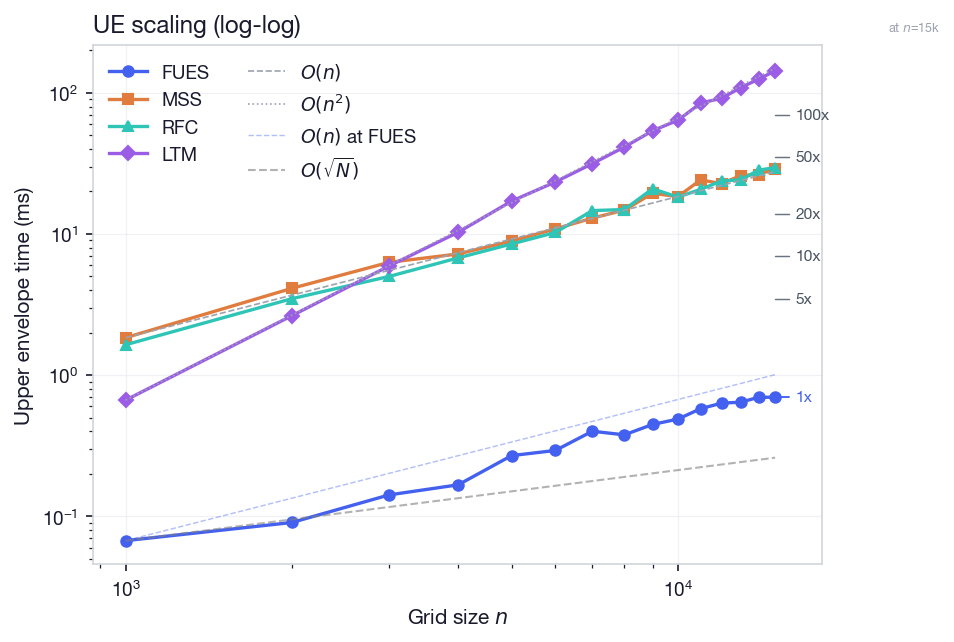

**Notebook scaling observations (live):**

The table below reports the upper-envelope time ratio `other method / FUES`, so larger numbers mean a larger speed advantage for FUES.

| Grid size | MSS / FUES | RFC / FUES | LTM / FUES |
|-----------|------------|------------|------------|
| 1,000 | 27.4x | 24.4x | 9.9x |
| 3,000 | 44.5x | 35.3x | 41.9x |
| 12,000 | 35.9x | 37.6x | 144.8x |

MSS and RFC scale linearly and remain close to one another across the sweep, while LTM scales quadratically and becomes much more expensive as the grid grows. FUES scales less than linearly

In [10]:
# ── Scaling plot with O(√N) reference line ──
from examples.retirement.outputs import nb_plot_scaling

fig = nb_plot_scaling(grid_sizes, scaling, methods=methods)
ax = fig.axes[0]

gs0 = grid_sizes[0]
t0 = scaling['FUES'][0]
ref_sqrt = [t0 * (gs / gs0) ** 0.5 for gs in grid_sizes]
ax.plot(grid_sizes, ref_sqrt, '--', color='gray', linewidth=1,
        alpha=0.6, label=r'$O(\sqrt{N})$')
ax.legend(ncol=2, frameon=False)

plt.show()

checkpoints = [1000, 3000, 12000]
idx_by_grid = {gs: i for i, gs in enumerate(grid_sizes)}

lines = [
    "**Notebook scaling observations (live):**",
    "",
    "The table below reports the upper-envelope time ratio `other method / FUES`, so larger numbers mean a larger speed advantage for FUES.",
    "",
    "| Grid size | MSS / FUES | RFC / FUES | LTM / FUES |",
    "|-----------|------------|------------|------------|",
]

for gs in checkpoints:
    i = idx_by_grid[gs]
    fues_t = scaling['FUES'][i]
    mss_ratio = scaling['DCEGM'][i] / fues_t
    rfc_ratio = scaling['RFC'][i] / fues_t
    ltm_ratio = scaling['CONSAV'][i] / fues_t
    lines.append(f"| {gs:,} | {mss_ratio:.1f}x | {rfc_ratio:.1f}x | {ltm_ratio:.1f}x |")

lines.extend([
    "",
    "MSS and RFC scale linearly and remain close to one another across the sweep, while LTM scales quadratically and becomes much more expensive as the grid grows. FUES scales less than linearly",
])

display(Markdown("\n".join(lines)))

Laptop and live notebook  timings can be noisy due to thermal throttling, OS scheduling, background processes and memory. The PBS cluster results below provide cleaner measurements on dedicated hardware.

## 6. PBS cluster timings (Gadi)

Compare the notebook scaling sweep (above) with timings from a PBS batch run on NCI Gadi.
The table below is parsed from a timing markdown file produced by `run.py --run-timings`.
We average UE time across all $\delta$ values for each grid size and method.

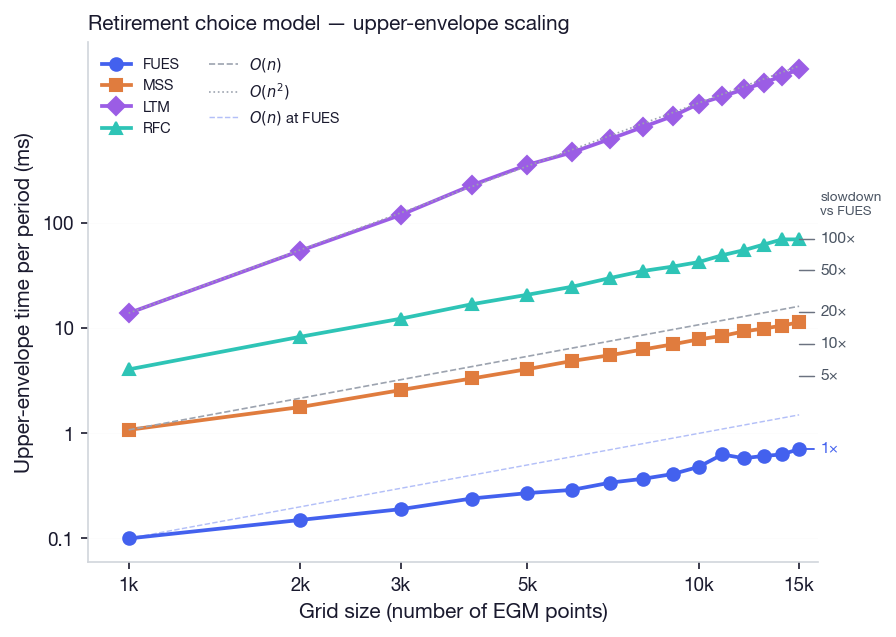

In [12]:
# ── PBS cluster timings ──
from nb_pbs import plot_pbs_scaling

timing_path = REPO / 'replication' / 'retirement' / '002' / \
    'tables' / 'retirement_timing.md'

fig = plot_pbs_scaling(timing_path)
plt.show()


In [ ]:
# ── Speedup ratio table (Gadi timings) ──
from nb_pbs import parse_timing_md

grid_sizes, means = parse_timing_md(timing_path)

show_grids = [1000, 3000, 6000, 10000, 15000]
show_grids = [g for g in show_grids if g in grid_sizes]

print("Upper-envelope time ratio (other / FUES), averaged across delta values.")
print()
header = "| {:>6s} | {:>10s} | {:>10s} | {:>10s} |".format("Grid", "MSS / FUES", "RFC / FUES", "LTM / FUES")
print(header)
print("|" + "-"*8 + "|" + "-"*12 + "|" + "-"*12 + "|" + "-"*12 + "|")
for g in show_grids:
    idx = grid_sizes.index(g)
    fues = means["FUES"][idx]
    if fues <= 0:
        continue
    mss = means["DCEGM"][idx] / fues
    rfc = means["RFC"][idx] / fues
    ltm = means["CONSAV"][idx] / fues
    print("| {:>6,d} | {:>9.0f}x | {:>9.0f}x | {:>9.0f}x |".format(g, mss, rfc, ltm))
